In [29]:
load("wild_mosaics.py")

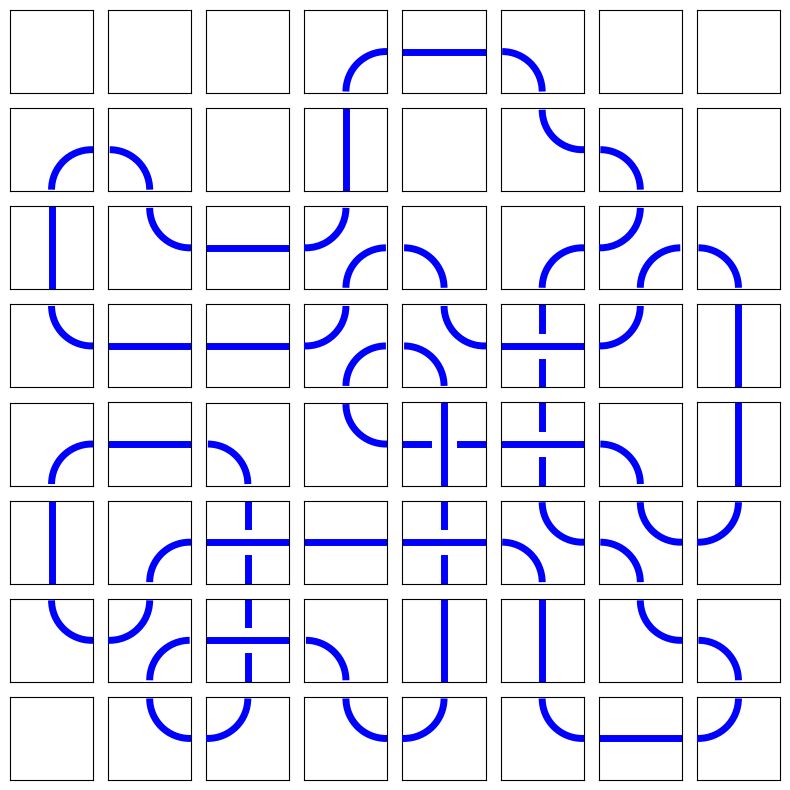

In [104]:
M = random_mosaic(8, suitably_connected = True, num_components = 1, num_crossings = 6)
M.show(8)

In [105]:
# internal function
def pick_starting_tile(M): #ensures starting tile is not crossing/hyperbolic tile
    strand_matrix = M.strandMatrix()
    for i in range(M.size):
        for j in range(M.size):
            if strand_matrix[i,j] == 1:
                return (i,j)

pick_starting_tile(M)

(0, 3)

In [ ]:

path = M.strandOf(pick_starting_tile(M)) 
path = list(enumerate(path)) # now path is list of (index, tile)

crossings = M.findCrossings()
appearances = []

for c in crossings:
    appearances += [(M.matrixRepresentation[c],c,index, path[index-1][1]) for index, tile in path if tile == c] # (tile, coord, index, previous coord)

appearances.sort()

orientations = []
for appearance in appearances:
    tile, coord, index, prev_coord = appearance
    orientations += [(tile, coord, M.strandOrientationAt(coord, prev_coord))]

crossings = list(dict.fromkeys([crossing for tile, crossing, orientation in orientations])) # ensures crossings in correct order
orientations


[(9, (3, 5), 'down'),
 (9, (3, 5), 'left'),
 (9, (4, 5), 'down'),
 (9, (4, 5), 'right'),
 (9, (5, 2), 'left'),
 (9, (5, 2), 'down'),
 (9, (5, 4), 'left'),
 (9, (5, 4), 'up'),
 (9, (6, 2), 'down'),
 (9, (6, 2), 'right'),
 (10, (4, 4), 'up'),
 (10, (4, 4), 'right')]

In [119]:
crossings

[(3, 5), (4, 5), (5, 2), (5, 4), (6, 2), (4, 4)]

In [ ]:
def crossing_handedness(tile_type, orientation_pair):
    assert tile_type in [9, 10]
    if tile_type == 9:
        if sorted(orientation_pair) == ["right", "up"]:
            return 1
        if sorted(orientation_pair) == ["down", "left"]:
            return 1
        if sorted(orientation_pair) == ["down", "right"]:
            return -1
        if sorted(orientation_pair) == ["left", "up"]:
            return -1

    if tile_type == 10:
        if sorted(orientation_pair) == ["up", "left"]:
            return 1
        if sorted(orientation_pair) == ["down", "right"]:
            return 1
        if sorted(orientation_pair) == ["down", "left"]:
            return -1
        if sorted(orientation_pair) == ["right", "up"]:
            return -1

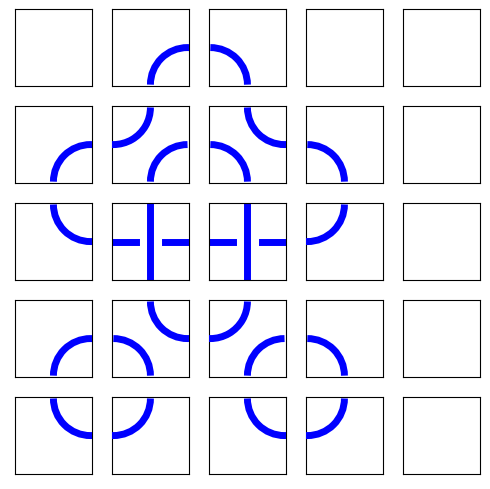

In [45]:
# mosaic = random_mosaic(dimension = 6, num_crossings=5); mosaic.show()
mosaic = Mosaic([[0,2,1,0,0],[2,8,7,1,0],[3,10,10,4,0],[2,7,8,1,0],[3,4,3,4,0]]); 
mosaic.show()

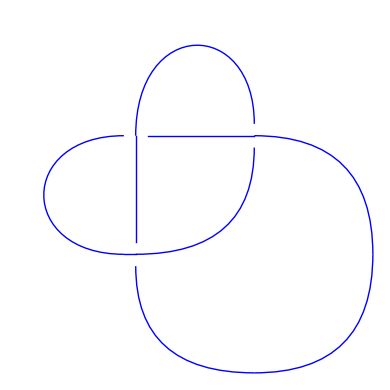

In [66]:
T = Link([[1, 5, 2, 4], [5, 3, 6, 2], [3, 1, 4, 6]]);
T.plot()

In [67]:
T.oriented_gauss_code()

[[[-1, 2, -3, 1, -2, 3]], [-1, -1, -1]]

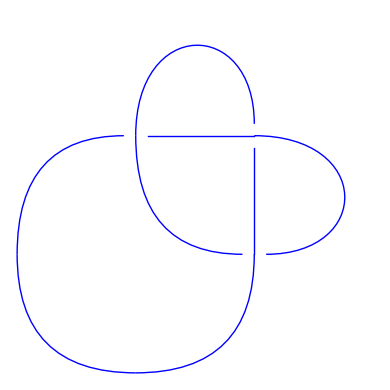

In [73]:
Link([[[1,-2,3,-1,2,-3]],[-1,-1,-1]]).plot()

In [47]:
mosaic.numComponents()

4

In [50]:
mosaic.strandMatrix()

[0 1 1 0 0]
[1 2 2 1 0]
[1 2 2 1 0]
[1 2 2 1 0]
[1 1 1 1 0]

In [48]:
mosaic.strands()[0]

[(0, 2),
 (1, 2),
 (1, 3),
 (2, 3),
 (2, 2),
 (2, 1),
 (2, 0),
 (1, 0),
 (1, 1),
 (0, 1)]

In [42]:
len(mosaic.strands()[1])

4

In [8]:
mosaic.strandOf((1,1),'left', verbose = True)

Went down into tile (2, 1).
Went down into tile (3, 1).
Went right into tile (3, 2).
Went up into tile (2, 2).
Went up into tile (1, 2).
Went left into tile (1, 1).


[((2, 1), 'down'),
 ((3, 1), 'down'),
 ((3, 2), 'right'),
 ((2, 2), 'up'),
 ((1, 2), 'up'),
 ((1, 1), 'left')]

In [9]:
M = mosaic.matrixRepresentation
M.nonzero_positions()

[(0, 1),
 (0, 2),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3),
 (4, 0),
 (4, 1),
 (4, 2),
 (4, 3)]

[ 0  2  1  0  0]
[ 2  8  7  1  0]
[ 3 10 10  4  0]
[ 2  7  8  1  0]
[ 3  4  3  4  0]

In [142]:
mosaic.strandMatrix()

[0 1 1 0 0]
[1 2 2 1 0]
[1 2 2 1 0]
[1 2 2 1 0]
[1 1 1 1 0]

In [ ]:
strand = mosaic.strandOf((1,0))

augmented_strandMatrix = mosaic.strandMatrix()

for tile in strand:
    augmented_strandMatrix[tile[0], tile[1]] -= 1 #decrease strand count by 1 for each tile in the strand

#augmented_strandMatrix

# sorted(L1) == sorted(L2) -- for later

def strands(mosaic):
    strands_list = []
    strandMatrix = mosaic.strandMatrix()
    while strandMatrix.nonzero_positions():
        start_tile = strandMatrix.nonzero_positions()[0]
        strand = mosaic.strandOf(start_tile)
        strands_list.append(strand)
        for tile in strand:
            strandMatrix[tile[0], tile[1]] -= 1
    return strands_list

testMatrix = mosaic.strandMatrix()
L = []
testMatrix.nonzero_positions()[0]
STRAND = mosaic.strandOf((3,0))
L.append(STRAND)
L
for tile in STRAND:
    testMatrix[tile[0], tile[1]] -= 1
testMatrix
testMatrix.nonzero_positions()[0]
STRAND = mosaic.strandOf((3,1)) # DIRECTION IS GONNA MATTER
L.append(STRAND)
L

#augmented_strandMatrix.nonzero_positions() # sage only

[[(4, 0), (4, 1), (3, 1), (3, 0)], [(3, 0), (4, 0), (4, 1), (3, 1)]]

In [25]:
len(mosaic.zoom().strandOf2((1,1),'left'))

48

In [119]:
mosaic2.findCrossings()

[(4, 4), (4, 7), (7, 7)]

In [122]:
len(mosaic2.strandOf2((4,4)))

60

In [51]:
M = mosaic.matrix(); M

[ 0  2  1  0]
[ 2 10  8  1]
[ 3  9 10  4]
[ 0  3  4  0]

In [114]:
# if not given direction, choose random connection direction of tile
def strandOf2(self, tile, direction = choice(flatten(Tile(M[tile]).connectionDirections))):
    start_tile = tile
    start_direction = direction

    path = []

    tile, direction = self.exitPath(start_tile[0],start_tile[1],opposite(start_direction))
    path += [tile]

    # keeping track of initial direction deals with 2 strand tiles starting-points!
    while not (tile == start_tile and direction == start_direction):
        tile, direction = self.exitPath(tile[0],tile[1],opposite(direction))
        path += [tile]

    return path

In [90]:
start_tile = (0,1)
start_direction = 'left'

path = []

tile, direction = mosaic.exitPath(start_tile[0],start_tile[1],opposite(start_direction))
path += [tile]

# keeping track of initial direction deals with 2 strand tiles starting-points!
while not (tile == start_tile and direction == start_direction):
   tile, direction = mosaic.exitPath(tile[0],tile[1],opposite(direction))
   path += [tile]

len(path)

16

In [55]:
mosaic.exitPath(1,1,'left') #outputs tile you end up at and direction you exit from
mosaic.exitPath(1,2,opposite('right'))

[(0, 2), 'up']

In [56]:
mosaic.exitPath(1,2,opposite('right')) 

[(0, 2), 'up']

In [ ]:
while tile != (1,1):
    
    mosaic.exitPath(tile[0],tile[1],)

mosaic.exitPath(1,1,'left')

(1, 2)

In [43]:
mosaic.exitPath(1,2,'left')

(1, 3)

In [22]:
mosaic.shift(0,1, dictionary = True)

{'down': (1, 1), 'right': (0, 2)}

In [15]:
mosaic.findCrossings()

[(1, 1), (1, 2), (2, 1)]

In [7]:
mosaic.shift(0,1, True) # want [[lower1, lower2], [upper1, upper 2]]
# then need to figure out for the hyperbolic tiles

{'down': (1, 1), 'right': (0, 2)}

In [42]:
Tile(7).connectionDirections

[['down', 'left'], ['up', 'right']]

In [ ]:
Mosaic()

In [ ]:
# for tile 7 want [[down, left], [up, right]]
# for tile 8 want [[down, right], [left, up]]
# for tile 9 want [[down, up], [left, right]], first always low strand
# for tile 10 want [[left, right], [up, down]]

# this is optional input for connection directions
# then implement into walk function
# then implmenet into strandof function